In [ ]:
import cupy as np

In [2]:
test = np.linspace(-1, 1, 10)

In [3]:
type(test)

cupy.ndarray

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from optiland import optic, analysis, wavefront, zernike
import torch
import optiland.backend as be

be.set_backend("torch")  # all calculations will be done using torch
be.set_precision("float64")  # or "float64" for double precision
be.grad_mode.enable()  # enable gradient calculation. Can also be set to "disable" to save memory if gradients are not needed.
be.set_device("cuda")  # run on GPU if available, otherwise use "cpu" option

/home/derbyk/miniconda3/envs/py310-env/lib/python3.10/site-packages/optiland/fields.py:185: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  (float(x / max_field), float(y / max_field))


(<Figure size 1000x400 with 1 Axes>, <Axes: xlabel='Z [mm]', ylabel='Y [mm]'>)

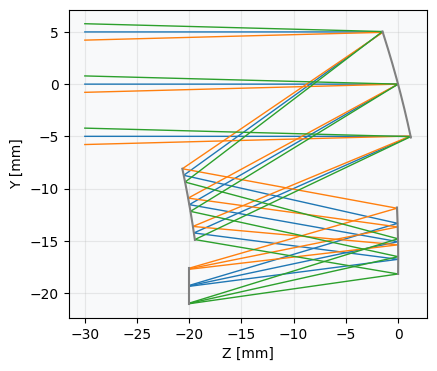

In [2]:
lens = optic.Optic(name="TMA")

# set aperture
lens.set_aperture(aperture_type="EPD", value=10)

# set fields
lens.set_field_type(field_type="angle")
lens.add_field(y=0)
lens.add_field(y=+1.5)
lens.add_field(y=-1.5)

# set wavelengths
lens.add_wavelength(value=0.550)
lens.add_wavelength(value=0.625, is_primary=True)
lens.add_wavelength(value=0.700)

# add surfaces
lens.add_surface(index=0, radius=np.inf, thickness=np.inf)

# these are optimized coefficients
c1 = np.array(
    [
        [2.05790534e-05, -2.04095791e-05, 4.55045366e-05, 1.47183545e-05],
        [3.64010850e-08, -9.18266382e-06, 3.12457789e-07, -3.43010757e-08],
        [-1.18212287e-04, 2.97963986e-06, -1.31354947e-06, 7.34797747e-07],
        [-1.09979245e-06, 8.55358588e-07, -3.94583506e-07, -5.01115270e-08],
    ],
)
lens.add_surface(
    index=1,
    radius=-99.9773,
    thickness=-20.0003,
    conic=2.35645e-06,
    material="mirror",
    rx=-0.261801,
    is_stop=True,
    surface_type="polynomial",
    coefficients=c1,
)

c2 = np.array(
    [
        [-2.05802662e-05, 2.05376130e-05, -2.91883756e-05, 4.01274602e-05],
        [-2.94473576e-08, -1.63268440e-06, -5.35655902e-06, -1.50920309e-05],
        [4.87006021e-05, -1.70308923e-05, 2.12362562e-05, 1.51092539e-05],
        [-1.04657810e-05, -2.25376153e-05, -8.02314506e-06, 3.02373985e-06],
    ],
)
lens.add_surface(
    index=2,
    radius=-100.019,
    thickness=20.0003,
    conic=-2.21455e-07,
    material="mirror",
    rx=-0.174532,
    dy=-11.5,
    surface_type="polynomial",
    coefficients=c2,
)

c3 = np.array(
    [
        [2.05787912e-05, -2.05604065e-05, 2.54616632e-05, -3.62841214e-05],
        [6.24577550e-10, 1.09936457e-07, -2.69199040e-06, -1.05068667e-05],
        [-3.28005504e-05, 1.88336844e-05, -3.34058539e-05, 4.93261709e-06],
        [6.09659324e-07, -1.58589636e-06, -1.16163570e-05, -2.26243673e-05],
    ],
)
lens.add_surface(
    index=3,
    radius=-99.9774,
    thickness=-20.0003,
    conic=5.32063e-08,
    material="mirror",
    rx=-0.0174547,
    dy=-15,
    surface_type="polynomial",
    coefficients=c3,
)

lens.add_surface(index=4, dy=-19.3)

lens.draw()

(<Figure size 1200x400 with 3 Axes>,
 [<Axes: title={'center': 'Hx: 0.000, Hy: 0.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: 1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>,
  <Axes: title={'center': 'Hx: 0.000, Hy: -1.000'}, xlabel='X (mm)', ylabel='Y (mm)'>])

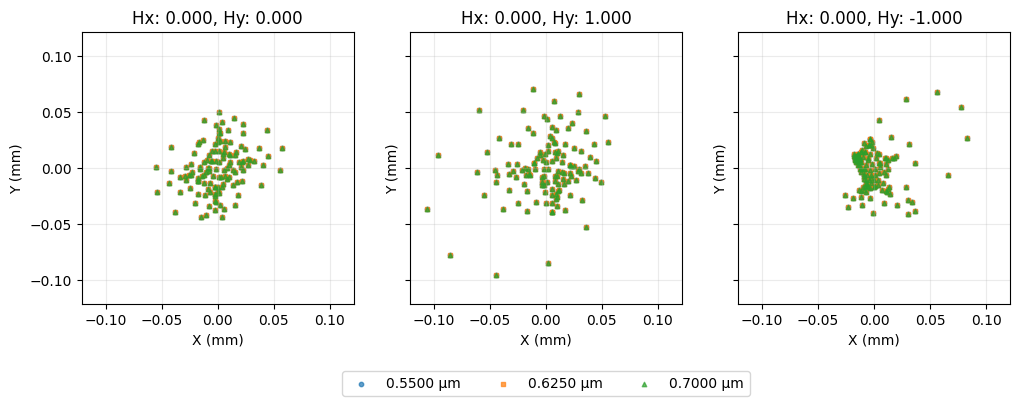

In [3]:
spot = analysis.SpotDiagram(lens)
spot.view()

(<Figure size 700x550 with 2 Axes>,
 <Axes: title={'center': 'OPD Map: RMS=1.434 waves'}, xlabel='Pupil X', ylabel='Pupil Y'>)

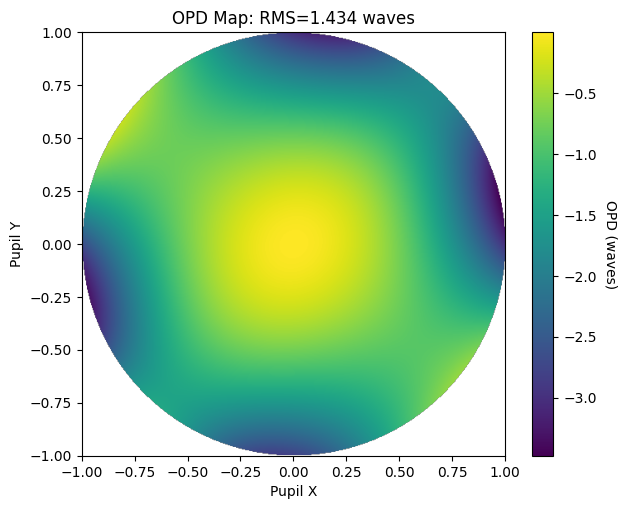

In [4]:
opd = wavefront.OPD(lens, field=(0, 0), wavelength=0.625)
opd.view(projection="2d", num_points=512)

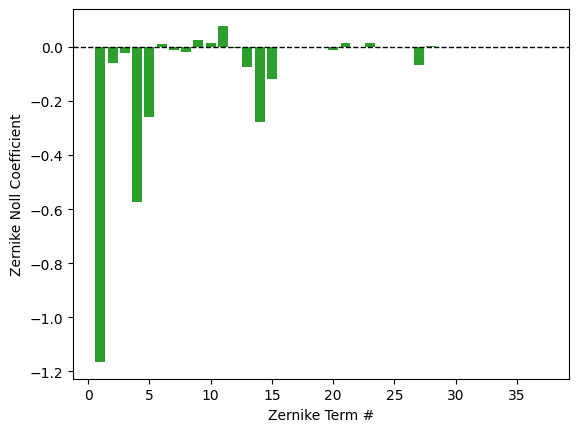

In [5]:
zernike_noll = wavefront.ZernikeOPD(
    lens,
    field=(0, 0),
    wavelength=0.625,
    zernike_type="noll",
    num_terms=37,
)

plt.bar(range(1, 38), zernike_noll.coeffs.cpu().detach().numpy(), color="C2")
plt.axhline(color="k", linewidth=1, linestyle="--")
plt.xlabel("Zernike Term #")
plt.ylabel("Zernike Noll Coefficient")
plt.show()

In [6]:
radius_params = []
surf_idx = []
for idx, surf in enumerate(lens.surface_group.surfaces):
    if not be.isinf(surf.geometry.radius):  # only add non-infinite radii
        # Create a new tensor for the radius with gradient tracking enabled
        r = (
            surf.geometry.radius.clone()
            .detach()
            .requires_grad_(True)
            .to(be.get_device())
        )
        surf.geometry.radius = r
        radius_params.append(r)
        surf_idx.append(idx)

In [80]:
z = opd.get_data(field=(0, 0), wl=0.625).opd
opd.distribution.x


tensor([ 0.0000e+00,  6.6667e-02,  3.3333e-02, -3.3333e-02, -6.6667e-02,
        -3.3333e-02,  3.3333e-02,  1.3333e-01,  1.1547e-01,  6.6667e-02,
         8.1643e-18, -6.6667e-02, -1.1547e-01, -1.3333e-01, -1.1547e-01,
        -6.6667e-02, -2.4493e-17,  6.6667e-02,  1.1547e-01,  2.0000e-01,
         1.8794e-01,  1.5321e-01,  1.0000e-01,  3.4730e-02, -3.4730e-02,
        -1.0000e-01, -1.5321e-01, -1.8794e-01, -2.0000e-01, -1.8794e-01,
        -1.5321e-01, -1.0000e-01, -3.4730e-02,  3.4730e-02,  1.0000e-01,
         1.5321e-01,  1.8794e-01,  2.6667e-01,  2.5758e-01,  2.3094e-01,
         1.8856e-01,  1.3333e-01,  6.9018e-02,  1.6329e-17, -6.9018e-02,
        -1.3333e-01, -1.8856e-01, -2.3094e-01, -2.5758e-01, -2.6667e-01,
        -2.5758e-01, -2.3094e-01, -1.8856e-01, -1.3333e-01, -6.9018e-02,
        -4.8986e-17,  6.9018e-02,  1.3333e-01,  1.8856e-01,  2.3094e-01,
         2.5758e-01,  3.3333e-01,  3.2605e-01,  3.0452e-01,  2.6967e-01,
         2.2304e-01,  1.6667e-01,  1.0301e-01,  3.4

In [7]:
# loss = opd.get_data(field=(0, 0), wl=0.625).opd[0]
loss = zernike_noll.coeffs[4]

loss.backward()

gradients = [r.grad.item() for r in radius_params]

RuntimeError: derivative for aten::floor_divide is not implemented

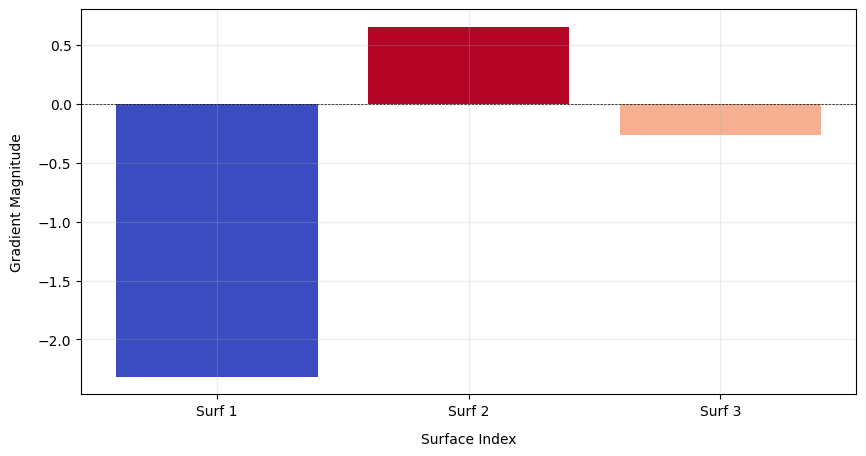

In [67]:
# plot the gradients
plt.figure(figsize=(10, 5))

gradients = np.array(gradients)
normalized_heights = (gradients - gradients.min()) / (gradients.max() - gradients.min())
cmap = plt.get_cmap("coolwarm")
colors = cmap(normalized_heights)

plt.bar(
    range(len(gradients)),
    gradients,
    color=colors,
    tick_label=[f"Surf {i}" for i in surf_idx],
)
plt.xlabel("Surface Index", labelpad=10)
plt.ylabel("Gradient Magnitude", labelpad=10)
plt.grid(alpha=0.25)
plt.axhline(0, color="black", lw=0.5, ls="--")
plt.show()